In [1]:
import numpy as np
import pandas as pd
import skimage
import matplotlib.pyplot as plt
import seaborn as sb

In [17]:
df = pd.read_csv('/scr/yren/all_data_micronuclei_no_rescale/metadata.csv')
subset = df[df.datasets == 'mnfinder_validation']
subset.filenames.to_list()[0]

'2022-05-26_RPE1-2198.phenotype.tif'

In [16]:
df.datasets.unique()

array(['HeLa', 'RPE1', 'pilot', 'screen', 'mnfinder_train',
       'mnfinder_test', 'mnfinder_validation', 'BBBC039'], dtype=object)

- screen

In [21]:
path = '/scr/yren/all_data_micronuclei_no_rescale/validation/'
screen_path = path + 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype.tif'
dinomn_path = '/scr/yren/figure4/dinomn_predictions/C2-20X_c0-DAPI-GFP_A2_Tile-5._probabilities.npy'

input_screen = skimage.io.imread(screen_path)
gt_screen = skimage.io.imread(screen_path.replace('phenotype.tif','phenotype_outlines.png'))
dinomn_screen = np.load(dinomn_path)
mnfinder_screen = np.load(dinomn_path.replace('dinomn', 'mnfinder'))
cellpose_screen = np.load(dinomn_path.replace('dinomn', 'cellpose'))
microsam_screen = np.load(dinomn_path.replace('dinomn', 'microSAM'))

- BBBC039

In [18]:
imid = 'IXMtest_N12_s7_w166EF3FAB-EA33-4B28-91E3-034A1654BAAE'
bbbc039_path = path + f'{imid}.phenotype.tif'
dinomn_path = f'/scr/yren/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_bbbc039 = skimage.io.imread(bbbc039_path)
gt_bbbc039 = skimage.io.imread(bbbc039_path.replace('phenotype.tif','phenotype_outlines.png'))
dinomn_bbbc039 = np.load(dinomn_path)
mnfinder_bbbc039 = np.load(dinomn_path.replace('dinomn', 'mnfinder'))
cellpose_bbbc039 = np.load(dinomn_path.replace('dinomn', 'cellpose'))
microsam_bbbc039 = np.load(dinomn_path.replace('dinomn', 'microSAM'))

- HeLa & RPE1

In [19]:
imid = 'C1-20X_c0_B3_Tile-24'
hela_rpe1_path = path + f'{imid}.phenotype.tif'
dinomn_path = f'/scr/yren/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_hela_rpe1 = skimage.io.imread(hela_rpe1_path)
gt_hela_rpe1 = skimage.io.imread(hela_rpe1_path.replace('phenotype.tif','phenotype_outlines.png'))
dinomn_hela_rpe1 = np.load(dinomn_path)
mnfinder_hela_rpe1 = np.load(dinomn_path.replace('dinomn', 'mnfinder'))
cellpose_hela_rpe1 = np.load(dinomn_path.replace('dinomn', 'cellpose'))
microsam_hela_rpe1 = np.load(dinomn_path.replace('dinomn', 'microSAM'))

- MNFinder Data

In [20]:
imid = '2022-05-26_RPE1-2198'
mnfinder_path = path + f'{imid}.phenotype.tif'
dinomn_path = f'/scr/yren/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_mnfinder = skimage.io.imread(mnfinder_path)
gt_mnfinder = skimage.io.imread(mnfinder_path.replace('phenotype.tif','phenotype_outlines.png'))
dinomn_mnfinder = np.load(dinomn_path)
mnfinder_mnfinder = np.load(dinomn_path.replace('dinomn', 'mnfinder'))
cellpose_mnfinder = np.load(dinomn_path.replace('dinomn', 'cellpose'))
microsam_mnfinder = np.load(dinomn_path.replace('dinomn', 'microSAM'))

# Grid Plot

In [22]:
inputs = [input_screen, input_bbbc039, input_hela_rpe1, input_mnfinder]
gt = [gt_screen, gt_bbbc039, gt_hela_rpe1, gt_mnfinder]
dinomn = [dinomn_screen, dinomn_bbbc039, dinomn_hela_rpe1, dinomn_mnfinder]
mnfinder = [mnfinder_screen, mnfinder_bbbc039, mnfinder_hela_rpe1, mnfinder_mnfinder]
cellpose = [cellpose_screen, cellpose_bbbc039, cellpose_hela_rpe1, cellpose_mnfinder]
microsam = [microsam_screen, microsam_bbbc039, microsam_hela_rpe1, microsam_mnfinder]

In [23]:
collections = [inputs, gt, dinomn, mnfinder, cellpose, microsam]

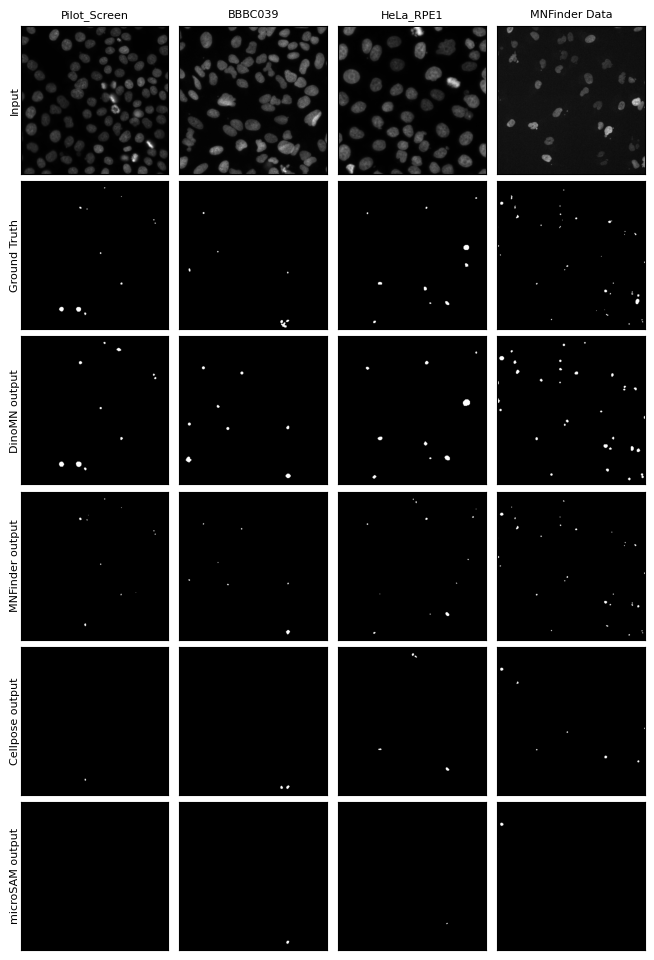

In [117]:
fig, ax = plt.subplots(6,4, figsize=(12,12))
plt.subplots_adjust(wspace=-0.65, hspace=0.05)


# Labels for columns and rows
col_labels = ['Pilot_Screen', 'BBBC039', 'HeLa_RPE1', 'MNFinder Data']
row_labels = ['Input', 'Ground Truth', 'DinoMN output', 'MNFinder output', 'Cellpose output', 'microSAM output']


for i in range(6):
    for j in range(4):
        if j==0:
            PS=700
            r,c = 2100,1300
        elif j == 1: # BBBC039
            PS = 400
            r,c = 50,100
        elif j==2:
            PS=500
            r,c = 1700,1900
        elif j==3:
            r,c = 150,300
        if i == 0:
            ax[i,j].imshow(collections[i][j][r:r+PS,c:c+PS], cmap='gray')
        else:
            ax[i,j].imshow(collections[i][j][r:r+PS,c:c+PS] > 0, cmap='gray')

        # Hide ticks but keep labels
        ax[i, j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        if i == 0:
            ax[i, j].set_title(col_labels[j], fontsize=8)

        # Set row labels on the left side
        if j == 0:
            # ax[i, j].set_ylabel(row_labels[i], fontsize=10, rotation=0, labelpad=30, va='center')
            ax[i, j].set_ylabel(row_labels[i], fontsize=8, rotation=90, va='center')


# plt.tight_layout()
plt.show()